In [ ]:
# Pair, linked-list, and Source Academy compatibility helpers are defined here.

import math

class Pair(tuple):
    """A Source Academy-style pair that also supports head/tail selectors."""

    def __new__(cls, head_value, tail_value):
        return super().__new__(cls, (head_value, tail_value))

    def __call__(self, selector):
        return selector(self[0], self[1])


def pair(head_value, tail_value):
    return Pair(head_value, tail_value)


def head(p):
    return p(lambda head_value, tail_value: head_value)


def tail(p):
    return p(lambda head_value, tail_value: tail_value)


def is_none(value):
    return value is None


def is_pair(value):
    return isinstance(value, Pair)


def llist(*values):
    result = None
    for value in reversed(values):
        result = pair(value, result)
    return result


def is_llist(value):
    current = value
    while is_pair(current):
        current = tail(current)
    return is_none(current)

def enum_llist(start, end):
    result = None
    for value in range(end, start - 1, -1):
        result = pair(value, result)
    return result

def print_llist(xs):
    values = []
    while not is_none(xs):
        values.append(str(head(xs)))
        xs = tail(xs)
    print(f"llist({', '.join(values)})")

def length(xs):
    return 0 if is_none(xs) else 1 + length(tail(xs))

def append(xs, ys):
    return (ys 
            if is_none(xs)
            else pair(head(xs), append(tail(xs), ys)))

def map(f, xs):
    return (None
            if is_none(xs)
            else pair(f(head(xs)), map(f, tail(xs))))

def filter(pred, xs):
    return (None
            if is_none(xs)
            else pair(head(xs), filter(pred, tail(xs)))
                if pred(head(xs))
                else filter(pred, tail(xs)))

def reduce(op, initial, xs):
    return (initial
            if is_none(xs)
            else op(head(xs), reduce(op, initial, tail(xs))))

def make_tree(entry, left, right):
    return pair(entry, pair(left, right))

# implementation of left_branch and right_branch and entry
def left_branch(tree):
    return head(tail(tree))

def right_branch(tree):
    return head(tail(tail(tree)))

def entry(tree):
    return head(tree)

def is_empty(tree):
    return is_none(tree)

def make_empty_tree():
    return make_tree(None, None, None)


details! <br>
All core material up to and including Week 5's Lectures, Paths, Missions, Reflections, Studios. <br>
probably includes curves & sound so gotta study allat... <br>

basically im gna make the cheatsheet here and copy paste from here later.

# PRACTICE A

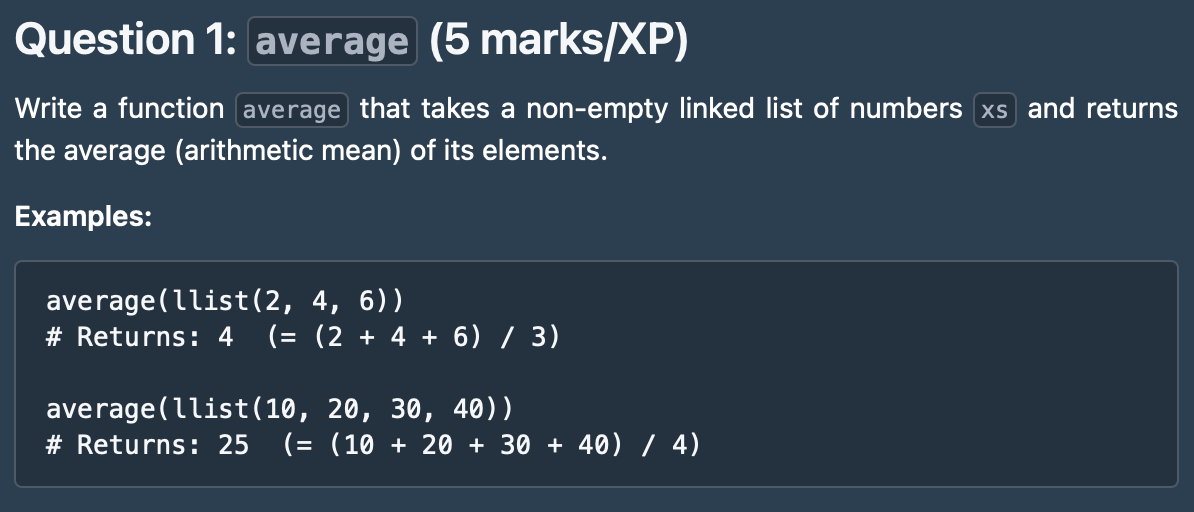

ok i fucking hate telling him hes smart and feeding his ego but this was smart only <br>
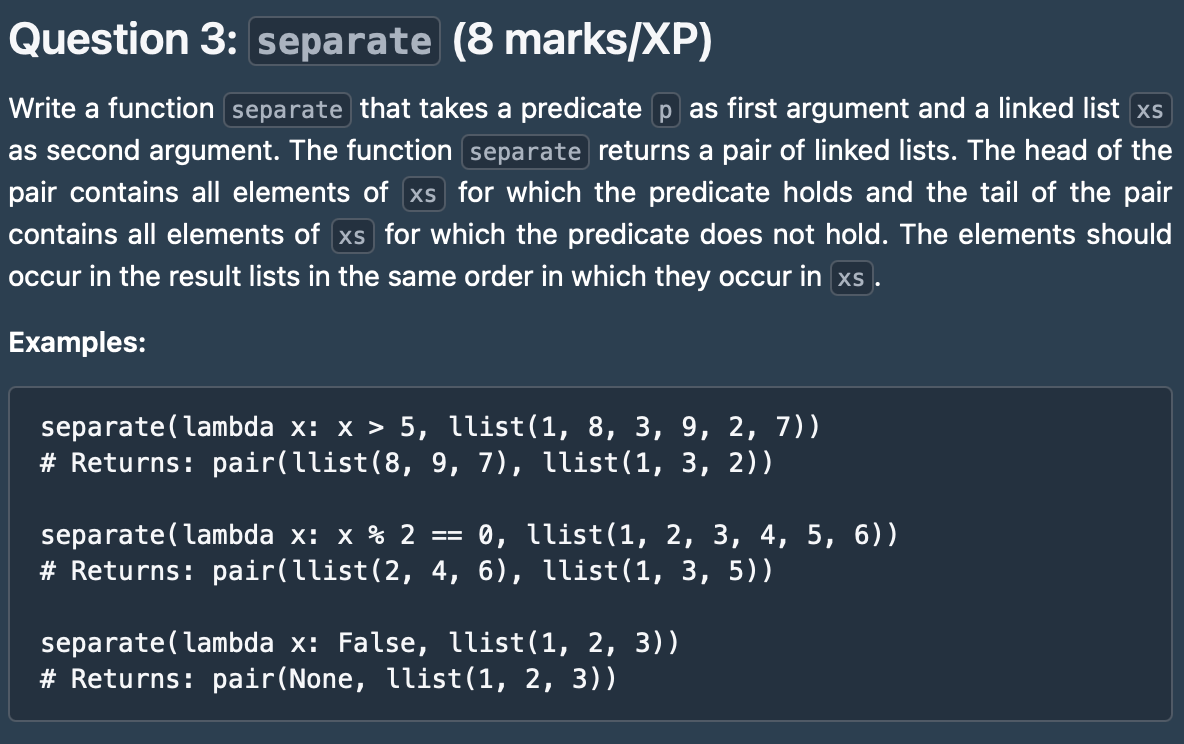

In [37]:
# my solution
def helper(x, ys): #want to check if am element x is not in ys
    if is_none(ys): return True
    elif x==head(ys): return False
    else: return helper(x, tail(ys))
    
def separate(p, xs):
    head = filter(p, xs)
    tail = filter(lambda x: helper(x, head), xs) #check if not in head
    return pair(head, tail)

# alternative solution (nandan's) (stfu this guy is too cracked im killing myself)

def separate2(p, xs):
    def helper2(fulfils, doesnt, p, xs): 
        if is_none(xs): 
            return pair(fulfils, doesnt)
        elif p(head(xs)): 
            return helper2(append(fulfils, llist(head(xs))), doesnt, p, tail(xs))
        else:
            return helper2(fulfils, append(doesnt, llist(head(xs))), p, tail(xs))
    return helper2(None, None, p, xs)

# Practical Exam 1
went horribly btw. i had 70mis for last 3 qns and cldnt solve them...
gna try them again rn

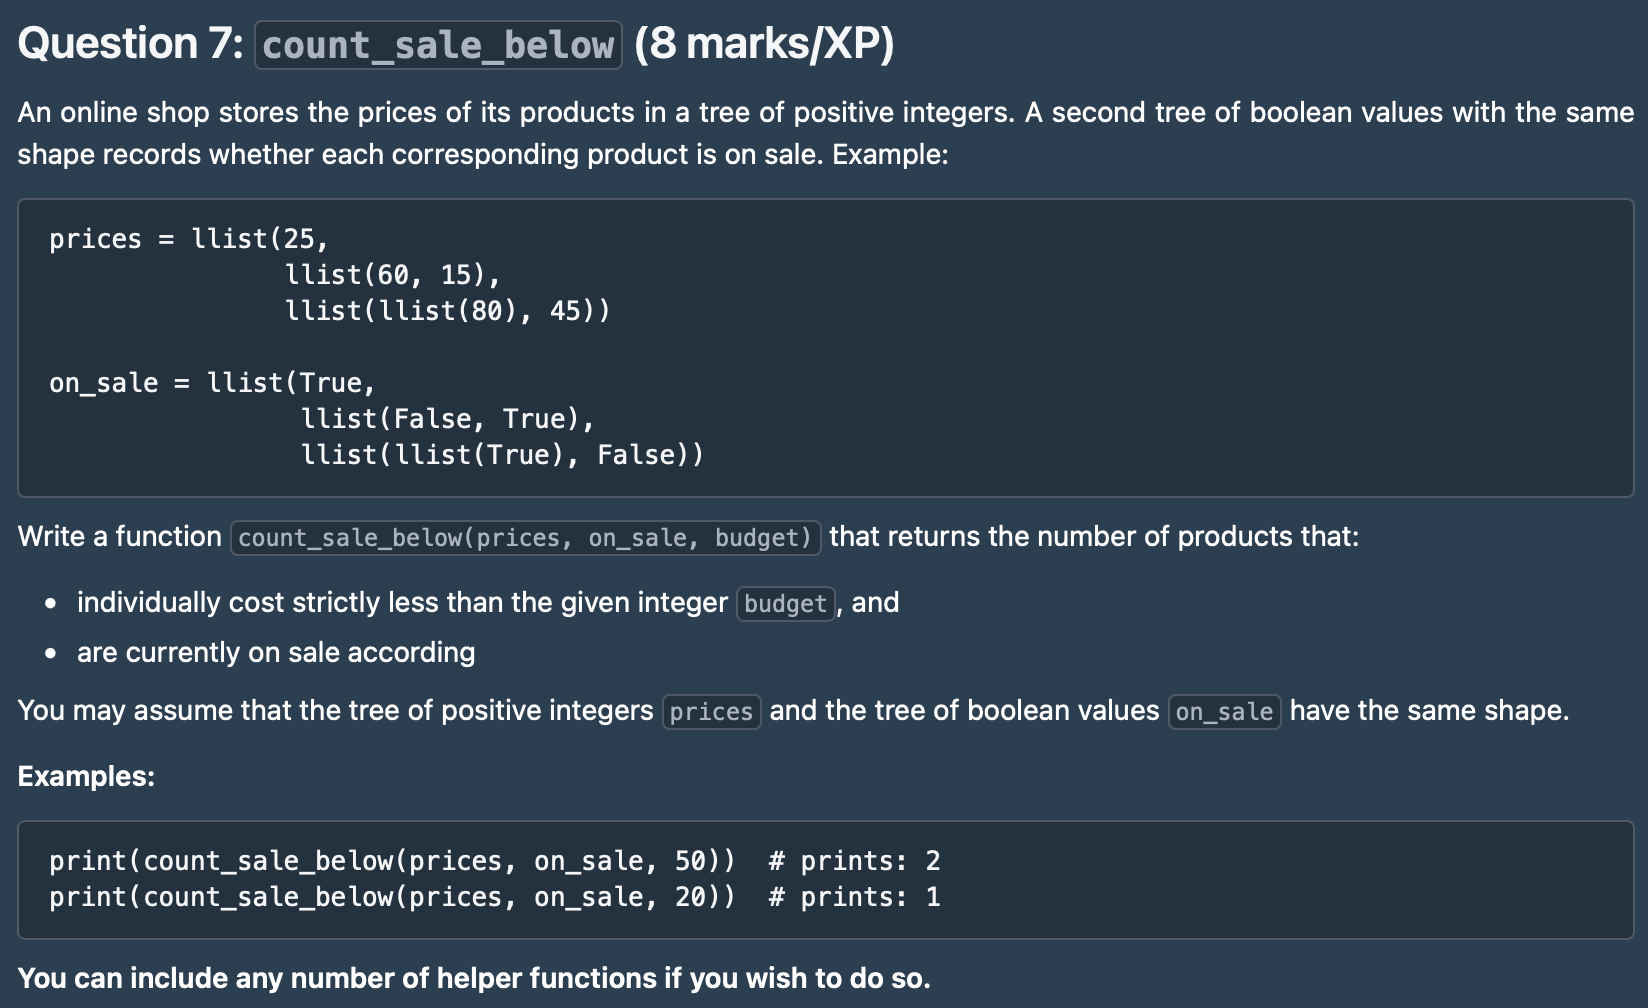

In [40]:
# example
prices = llist(25, llist(60, 15), llist(llist(80), 45))
onsale = llist(True, llist(False, True), llist(llist(True), False))

def create_pair(prices, onsale): 
    # wish that tree of pairs has been created for the left and right branches
    # wish1 = create_pair(left_branch(prices), left_branch(onsale)) ; wish2 = create_pair(right_branch(prices), right_branch(onsale))
    # so make_tree(entry, wish1, wish2)
    # base case: when prices is empty (onsale wld also be empty) -> return None
    if is_none(prices): 
        return make_empty_tree()
    else:
        return make_tree(pair(entry(prices), entry(onsale)),
                         create_pair(left_branch(prices), left_branch(onsale)),
                         create_pair(right_branch(prices), right_branch(onsale)))

print_llist(create_pair(prices, onsale))

# def count_sale_below(prices, onsale, budget):
#     # wish that u knew the count for the leftbranch and rightbranch
#     # wish1 = count_sale_below(left_branch(prices), left_branch(onsale), budget)
#     # wish2 = count_sale_below(right_branch(prices), right_branch(onsale), budget)
#     # if head(entry) < budget and tail(entry)==True -> wish1+wish2+1
#     # else -> wish1+wish2
#     # base case -> new_tree is empty -> return 0
#     new_tree = create_pair(prices, onsale)
#     if is_empty(new_tree): 
#         return 0
#     elif not is_llist(left_branch(new_tree)): 
#         return ...
#     elif head(entry(new_tree)) < budget and tail(entry(new_tree)) == True:
#         return count_sale_below(left_branch(prices), left_branch(onsale), budget) + count_sale_below(right_branch(prices), right_branch(onsale), budget) + 1
#     else:
#         return count_sale_below(left_branch(prices), left_branch(onsale), budget) + count_sale_below(right_branch(prices), right_branch(onsale), budget)

# count_sale_below(prices, onsale, 50)

TypeError: 'int' object is not callable